# Employee Sentiment & Culture Analysis — UK Glassdoor Reviews
### People Analytics | Predicting Employee Advocacy from Multi-Dimensional Review Data
**Zikra Aditia — People Analytics & Data Science**

## Section 0 — Executive Summary

### Section 0a — Summary

**The problem.** Nearly one in three employees who bother to give an opinion (29%) 
would not recommend their employer. For a 1,000-person organization, that low advocacy 
works out to somewhere between £1.15M and £2.69M a year in cost, once you count lost 
productivity, absenteeism, and turnover risk.

**What drives it.** Advocacy runs mostly on Culture & Values, then Senior Management 
and Career Opportunities, and two independent methods agree on that order. Compensation 
turns out to be a secondary, hygiene-type factor. Pay matters, but it isn't the lever. 
Culture and leadership also feed off each other: when both are strong, 98% of employees 
recommend; when both are weak, only 12% do.

**What employees actually say.** The text backs the numbers up. Detractors complain 
about management 2.5 times as much as promoters do. And promoters, tellingly, gripe 
more about long hours than detractors do yet still recommend anyway, which tells you 
rough conditions are tolerable but bad management is a deal-breaker.

**The model.** A model spots would-not-recommend reviews with 86% recall, which is what 
makes the High/Medium/Low risk tiers useful for HR to triage against.

**The recommendation.** Put leadership and culture first. They're higher-impact and 
cheaper to move than blanket pay rises, and where both are weak they have to be tackled 
together, not one at a time. Then prove it works with a randomized pilot before rolling 
out wide.

**Bottom line:** the biggest lever on employee advocacy is the quality of leadership, 
not pay, and it's more within reach than the cost figure makes it sound.

### Section 0b — Reproducibility Config

In [1]:
import sys
!{sys.executable} -m pip install bertopic sentence-transformers


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import torch
print("CUDA tersedia:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA tersedia: False
GPU: CPU only


In [3]:
# ============================================================
# REPRODUCIBILITY CONFIGURATION
# Project 2 — Glassdoor Employee Sentiment & Culture
# ============================================================
import random
import numpy as np
import pandas as pd
import sys
!{sys.executable} -m pip install pandas numpy scikit-learn matplotlib seaborn wordcloud nltk

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 80)

# Midnight Executive palette (konsisten di semua chart)
NAVY   = '#1E2761'   # primary, baseline bars
ORANGE = '#E67E22'   # accent, alert, risk highlight
RED    = '#E74C3C'   # danger, high risk
GREEN  = '#27AE60'   # positive, low risk, target met
GRAY   = '#7F8C8D'   # labels, context

# Chart defaults
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize']  = (10, 6)
plt.rcParams['axes.grid']       = True
plt.rcParams['grid.alpha']      = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print(f"✅ Config loaded. RANDOM_STATE = {RANDOM_STATE}")
print(f"   pandas {pd.__version__} | numpy {np.__version__}")


[notice] A new release of pip is available: 24.3.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Config loaded. RANDOM_STATE = 42
   pandas 3.0.3 | numpy 2.4.6


## Section 1 — Project Overview

This project looks at more than 800,000 employee reviews from Glassdoor UK, posted 
between 2008 and 2021, to answer one question: what makes employees recommend their 
workplace, and what makes them refuse to?

Each review comes with six sub-ratings (work-life balance, culture and values, 
career opportunities, compensation and benefits, senior management, and diversity 
and inclusion), three categorical signals about whether the reviewer recommends the 
company, approves of the CEO, and feels good about its outlook, plus free-text Pros 
and Cons where people say what they really think.

One thing shapes the whole analysis. The data is anonymous and sits at the review 
level, not the individual-employee level. There is no way to track who left or who 
stayed, so this project doesn't try to predict turnover directly. Instead, it uses 
the "recommend" field as a stand-in for employee advocacy and retention intent, 
which is an honest proxy given what the data can and can't tell us.

The work combines two angles. The numbers show which sub-ratings separate the 
employees who recommend from those who don't. The text, through NLP, surfaces the 
cultural themes and specific complaints that ratings alone would miss. From there 
the project moves through driver diagnosis, a predictive model, risk scoring, and 
finally cost-justified recommendations for what HR should actually do.

The audience is CEO and CHRO stakeholders, so everything is framed for strategic 
decisions and clear priorities rather than modeling detail.

## Section 2 — Business Context & Objective

### 2.1 — The starting point: nearly one in three won't recommend their employer

Among employees who gave a clear opinion, 29% would not recommend their company to 
a friend. That number matters more than it first looks. People tend to answer these 
questions on the positive side, so a healthy "recommend to a friend" score usually 
sits at 70% or above, and anything near 50% is a warning sign. Our overall rate is 
71%, which lands right on the edge of healthy. But an average hides the real story. 
The value is in finding the companies, roles, and themes that fall well below that 
line, and understanding why.

There's a second signal pointing the same way: 16% of all reviews give an overall 
rating of two stars or lower. That's a sizable group of unhappy employees whose 
dissatisfaction, if nobody diagnoses it, quietly turns into cost.

### 2.2 — Why it's a problem: the cost of low advocacy

Low advocacy isn't just a reputation issue, it's a financial one. Gallup research 
puts the cost of a single actively disengaged employee at around 34% of their annual 
salary, once you account for lost productivity, absenteeism, and higher turnover 
risk. Our data measures advocacy rather than engagement directly, but the two are 
closely tied in the HR literature: people who actively won't recommend their employer 
are far more likely to be disengaged and thinking about leaving.

To make this tangible, we can model the exposure for a hypothetical 1,000-person 
organization, using the UK median full-time salary of £39,000 (ONS, 2025) as a 
stand-in. Since we can't know exactly how many detractors are genuinely disengaged, 
we show three scenarios instead of pretending to know a single figure.

> Even on the most conservative assumption, low advocacy carries an estimated £1.15M 
> in annual cost for a 1,000-person organization, rising to £2.69M on an aggressive 
> one.

### 2.3 — The Objective

The goal is to give CEO and CHRO stakeholders a clear, ranked answer to three 
questions: what drives employees to recommend their employer or not, what they're 
actually saying about culture and grievances, and where to act first for the biggest 
return. The end product is a diagnostic that turns messy employee sentiment into 
prioritized, cost-justified HR actions.

**Deliverables:** this analytical notebook, a CEO/CHRO presentation deck, and an 
interactive Streamlit dashboard for ongoing use.

### 2.4 — A note on how the cost is estimated

These figures are illustrative. They're built on external benchmarks rather than 
internal financial data, and they rest on assumptions worth stating plainly: the 
"recommend" field stands in for advocacy and retention intent, since the dataset has 
no attrition or salary columns; the 34%-of-salary cost is a Gallup benchmark applied 
across the board; salary is held at the 2025 UK median to express the cost in today's 
money, even though the reviews span 2008–2021; and because we don't know what share 
of detractors are truly disengaged, we present it as a 30/50/70% range. The point is 
to size the opportunity, not to produce an exact accounting figure. Every assumption 
is on the table for the reader to push back on.

## Section 3 — Business Questions

Everything that follows is built around four questions. They're written the way a 
CEO would ask them, not the way a data scientist would, and each one points to the 
part of the notebook that answers it.

**Q1 — Why do employees choose not to recommend their employer?**  
Of the five sub-ratings we can analyze (culture, senior management, compensation, 
career opportunities, work-life balance), which ones actually separate the people 
who recommend from the people who don't? *Answered in Sections 6 and 9.*

**Q2 — What are employees actually saying, in their own words?**  
The ratings tell us the "how much." The free text tells us the "what." Which 
complaints and which points of praise keep coming up, and which ones travel with low 
advocacy? *Answered in the NLP module.*

**Q3 — Who is most at risk, and can we see it coming?**  
Can we reliably flag a "would-not-recommend" review from its sub-ratings, so the 
organization can spot at-risk groups before the dissatisfaction spreads? *Answered 
in Sections 8 and 10.*

**Q4 — What should the organization do, and what's the payoff?**  
Given what drives advocacy and what people are complaining about, where should HR 
spend its effort first, and what's the cost-benefit of doing so? *Answered in 
Sections 11 and 12.*

Read together, the four move from understanding the problem (why, what) to spotting 
it (who) to acting on it (how). It's the same path a CEO and CHRO would walk, in the 
same order.

## Section 4 — Data Loading & Understanding

### 4.1 — Data Loading

Before touching anything, we load the data and take stock of what's actually there: 
how many records, which columns, what types, and where the gaps are. Nothing gets 
changed here. This is just an honest inventory.

In [4]:
import pandas as pd
import numpy as np

# --- Load the full dataset ---
df = pd.read_csv('glassdoor_reviews.csv')   # adjust filename if different

# --- Basic shape ---
print("="*55)
print(f"DATASET: {df.shape[0]:,} reviews × {df.shape[1]} columns")
print("="*55)

# --- Column overview ---
print("\n--- COLUMNS & DATA TYPES ---")
print(df.dtypes)

# --- Missing data audit ---
print("\n--- MISSING DATA (columns with gaps) ---")
missing = (df.isnull().sum() / len(df) * 100).round(1)
missing = missing[missing > 0].sort_values(ascending=False)
for col, pct in missing.items():
    print(f"  {col:<22} {pct:>5}% missing")

# --- Time coverage ---
print("\n--- TIME COVERAGE ---")
print(f"  From {df['date_review'].min()} to {df['date_review'].max()}")

# --- Cardinality of key identifiers ---
print("\n--- SCOPE ---")
print(f"  Unique firms:       {df['firm'].nunique():,}")
print(f"  Unique job titles:  {df['job_title'].nunique():,}")
print(f"  Unique locations:   {df['location'].nunique():,}")

# --- First look ---
print("\n--- SAMPLE ROWS ---")
df.head(3)

DATASET: 838,566 reviews × 18 columns

--- COLUMNS & DATA TYPES ---
firm                       str
date_review                str
job_title                  str
current                    str
location                   str
overall_rating           int64
work_life_balance      float64
culture_values         float64
diversity_inclusion    float64
career_opp             float64
comp_benefits          float64
senior_mgmt            float64
recommend                  str
ceo_approv                 str
outlook                    str
headline                   str
pros                       str
cons                       str
dtype: object

--- MISSING DATA (columns with gaps) ---
  diversity_inclusion     83.8% missing
  location                35.5% missing
  culture_values          22.8% missing
  senior_mgmt             18.6% missing
  work_life_balance       17.9% missing
  comp_benefits           17.9% missing
  career_opp              17.6% missing
  headline                 0.3% missin

,firm,date_review,job_title,current,location,overall_rating,work_life_balance,culture_values,diversity_inclusion,career_opp,comp_benefits,senior_mgmt,recommend,ceo_approv,outlook,headline,pros,cons
0,AFH-Wealth-Management,2015-04-05,,Current Employee,NaN,2,4.0,3.0,NaN,2.0,3.0,3.0,x,o,r,"Young colleagues, poor micro management",Very friendly and welcoming to new staff. Easy going ethic.,"Poor salaries, poor training and communication."
1,AFH-Wealth-Management,2015-12-11,Office Administrator,"Current Employee, more than 1 year","Bromsgrove, England, England",2,3.0,1.0,NaN,2.0,1.0,4.0,x,o,r,"Excellent staff, poor salary","Friendly, helpful and hard-working colleagues","Poor salary which doesn't improve much with progression, no incentive to wor..."
2,AFH-Wealth-Management,2016-01-28,Office Administrator,"Current Employee, less than 1 year","Bromsgrove, England, England",1,1.0,1.0,NaN,1.0,1.0,1.0,x,o,x,"Low salary, bad micromanagement",Easy to get the job even without experience in finance,"Very low salary, poor working conditions, very little training provided but ..."


### What the data tells us

We're working with roughly 838,000 UK employee reviews spanning April 2008 to June 
2021, thirteen years in all, across 428 firms and thousands of job titles and 
locations. The columns fall into a few natural groups:

- **Identifiers** — firm, date, job title, whether the person is a current or former 
  employee, and location
- **Numeric ratings** — an overall rating plus six sub-ratings (work-life balance, 
  culture and values, career opportunities, compensation and benefits, senior 
  management, and diversity and inclusion)
- **Categorical signals** — recommend, CEO approval, and business outlook, coded v/r/x/o
- **Free text** — headline, pros, and cons, which is where the employee's real voice 
  lives

Three data-quality problems stand out, and we deal with them in Section 5:

1. **`diversity_inclusion` is about 84% empty.** Glassdoor added this rating only in 
   later years, so most older reviews simply don't have it. There's no honest way to 
   use it as a core variable, so it gets dropped.
2. **`location` is about 36% empty.** Usable, but incomplete, so any location-based 
   read has to account for the gap.
3. **The five main sub-ratings are 18–23% empty.** That's a meaningful chunk. Section 
   5 decides between dropping those rows and filling them in, with a clear reason 
   either way.

The good news is the free text is nearly complete (the headline is only about 0.3% 
missing), which matters a lot for the NLP work later. The voice-of-employee data is 
intact.

## Section 5 — Data Cleaning & Preprocessing

We clean the data in a deliberate order, because the order turns out to matter. If 
you drop rows for the most fundamental reason first (defining the target), a lot of 
the missing-data problem disappears on its own as a side effect. That's not luck. 
It's a pattern we checked before committing to it.

### 5.1 — Cleaning Sequence : 

1. Drop `diversity_inclusion` (about 84% empty, can't be a core variable)
2. Remove corrupted scraping artifacts
3. Define the target: drop "no opinion" (`o`), keep recommend (`v`) versus not (`x`)
4. Drop rows still missing sub-ratings (shown to be safe once step 3 is done)
5. Report every row removed, out in the open

Each step prints how many rows are left, so anyone reading can audit exactly what 
went and why.

In [5]:
# ============================================================
# Section 5 — Data Cleaning (transparent, step-by-step)
# ============================================================
print(f"START: {len(df):,} rows\n")

sub_ratings = ['work_life_balance','culture_values','career_opp',
               'comp_benefits','senior_mgmt']

# --- STEP 1: Drop diversity_inclusion (84% missing) ---
df_clean = df.drop(columns=['diversity_inclusion'])
print(f"[1] Dropped 'diversity_inclusion' column (84% missing)")
print(f"    Rows unchanged: {len(df_clean):,}\n")

# --- STEP 2: Remove corrupted scraping artifacts ---
# The 'current' column contains occasional scraper errors like 'KEY NOT FOUND: ...'
before = len(df_clean)
df_clean = df_clean[~df_clean['current'].astype(str).str.contains('KEY NOT FOUND', na=False)]
print(f"[2] Removed corrupted rows: {before - len(df_clean):,}")
print(f"    Rows remaining: {len(df_clean):,}\n")

# --- STEP 3: Define target — drop 'o', keep v vs x ---
before = len(df_clean)
df_clean = df_clean[df_clean['recommend'].isin(['v','x'])].copy()
# Binary target: 1 = would recommend, 0 = would not recommend
df_clean['target'] = (df_clean['recommend'] == 'v').astype(int)
print(f"[3] Dropped 'no opinion' (o): {before - len(df_clean):,}")
print(f"    Rows remaining (v vs x): {len(df_clean):,}")
print(f"    Target balance: {df_clean['target'].mean():.1%} recommend / "
      f"{1-df_clean['target'].mean():.1%} not\n")

# --- STEP 4: Drop rows with any remaining missing sub-rating ---
before = len(df_clean)
df_clean = df_clean.dropna(subset=sub_ratings)
print(f"[4] Dropped rows with missing sub-ratings: {before - len(df_clean):,}")
print(f"    Rows remaining: {len(df_clean):,}\n")

# --- STEP 5: Final summary ---
print("="*50)
print(f"FINAL CLEAN DATASET: {len(df_clean):,} rows")
print(f"Retained {len(df_clean)/len(df)*100:.1f}% of original data")
print(f"Target: {df_clean['target'].sum():,} recommend / "
      f"{(df_clean['target']==0).sum():,} not recommend")
print("="*50)

START: 838,566 rows

[1] Dropped 'diversity_inclusion' column (84% missing)
    Rows unchanged: 838,566

[2] Removed corrupted rows: 3
    Rows remaining: 838,563

[3] Dropped 'no opinion' (o): 234,247
    Rows remaining (v vs x): 604,316
    Target balance: 70.8% recommend / 29.2% not

[4] Dropped rows with missing sub-ratings: 55,165
    Rows remaining: 549,151

FINAL CLEAN DATASET: 549,151 rows
Retained 65.5% of original data
Target: 389,916 recommend / 159,235 not recommend


### 5.2 — What the cleaning left us

Starting from about 838,000 raw reviews, we end up with 549,151 that are ready to 
analyze, a comfortable 65.5% of the original. The biggest single cut is the "no 
opinion" group, roughly 28% of the data. Worth being clear about this: those rows 
were dropped by design, because "no opinion" carries no real recommendation signal, 
not because anything was wrong with them.

Here's the part that made the order matter. Before dropping anything, we checked 
whether the rows missing sub-ratings were spread randomly. They weren't. They 
overlapped heavily with the "no opinion" crowd. So by defining the target first and 
dropping `o`, that bias cleared out on its own. The small slice of missing 
sub-ratings that remained (around 9%) split almost identically to the complete rows 
on recommend-versus-not, which told us they were safe to drop without skewing 
anything.

What's left has a target balance of about 71% recommend to 29% not-recommend. It's 
a mild imbalance, and we handle it during modeling with balanced class weighting.

## Section 6 — Exploratory Data Analysis

Our approach here is domain-driven, not correlation-driven. On a binary target, raw 
correlation coefficients quietly understate the strong drivers, so instead we compare 
recommend rates across rating levels and back it up with chi-square tests. And before 
reading anything into a segment, we check how much data it actually holds, so we don't 
build a story on thin air.

The six sub-ratings sort naturally into three families: the cultural ones (Culture & 
Values, Senior Management), growth (Career Opportunities), and conditions 
(Compensation, Work-Life Balance). Diversity & Inclusion sat this one out, dropped 
back in Section 5 for being mostly empty.

### 6.1 — Which factors actually drive advocacy?

For each sub-rating, we compare the recommend rate when people score it low (1–2) 
against when they score it high (4–5). The gap between those two tells us how much 
that factor moves the decision to recommend. Bigger gap, stronger driver. Simple as 
that.

In [6]:
sub_ratings = ['culture_values','career_opp','senior_mgmt','comp_benefits','work_life_balance']
labels = {'culture_values':'Culture & Values','career_opp':'Career Opportunities',
          'senior_mgmt':'Senior Management','comp_benefits':'Compensation',
          'work_life_balance':'Work-Life Balance'}

rows = []
for col in sub_ratings:
    low  = df_clean[df_clean[col]<=2]['target'].mean()
    high = df_clean[df_clean[col]>=4]['target'].mean()
    rows.append({'Driver':labels[col],'Low (1-2)':low,'High (4-5)':high,'Gap':high-low})

driver_df = pd.DataFrame(rows).sort_values('Gap', ascending=False).reset_index(drop=True)
print(driver_df.to_string(index=False, formatters={
    'Low (1-2)':'{:.0%}'.format,'High (4-5)':'{:.0%}'.format,'Gap':'{:.0%}'.format}))

              Driver Low (1-2) High (4-5) Gap
    Culture & Values       17%        93% 77%
Career Opportunities       24%        92% 68%
   Senior Management       28%        96% 68%
        Compensation       33%        88% 56%
   Work-Life Balance       38%        88% 50%


### 6.2 — Ranking the drivers visually

We plot the recommend-rate gap as a horizontal bar chart, with the strongest driver 
picked out in orange. (In the Midnight Executive palette, color means "look here," 
not decoration.)

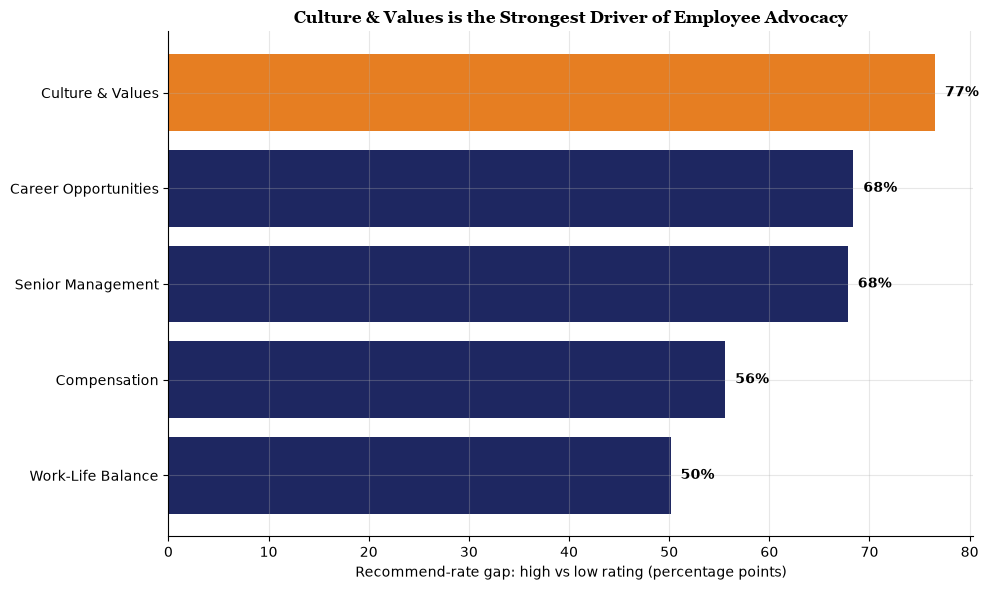

In [7]:
fig, ax = plt.subplots(figsize=(10,6))
colors = [ORANGE if g == driver_df['Gap'].max() else NAVY for g in driver_df['Gap']]
ax.barh(driver_df['Driver'], driver_df['Gap']*100, color=colors)
ax.invert_yaxis()
ax.set_xlabel('Recommend-rate gap: high vs low rating (percentage points)')
ax.set_title('Culture & Values is the Strongest Driver of Employee Advocacy',
             fontweight='bold', fontfamily='Georgia')
for i, g in enumerate(driver_df['Gap']):
    ax.text(g*100+1, i, f'{g:.0%}', va='center', fontweight='bold')
plt.tight_layout(); plt.show()

**Reading the chart.** Culture & Values shows the widest gap by a clear margin. People who rate culture 
poorly almost never recommend the company; people who rate it highly almost always 
do. Compensation, meanwhile, lands fourth. It matters, but it's weaker than culture, 
career, and leadership, which fits the idea of pay as a "hygiene factor": its absence 
frustrates people, but its presence alone doesn't win them over.

### 6.3 — Checking it holds up statistically

The gaps show us magnitude. Chi-square tells us whether each relationship is real or 
just noise. We report the statistic, the p-value, and whether it clears significance 
for every driver.

In [8]:
from scipy.stats import chi2_contingency

val = []
for col in sub_ratings:
    binned = pd.cut(df_clean[col], bins=[0,2,3,5], labels=['low','mid','high'])
    chi2, p, dof, _ = chi2_contingency(pd.crosstab(binned, df_clean['target']))
    val.append({'Driver':labels[col],'Chi-square':round(chi2,1),
                'p-value':f'{p:.1e}','Significant':'Yes ***' if p<0.001 else 'No'})

chi_df = pd.DataFrame(val).sort_values('Chi-square', ascending=False)
print(chi_df.to_string(index=False))

              Driver  Chi-square p-value Significant
    Culture & Values    250614.6 0.0e+00     Yes ***
   Senior Management    229511.1 0.0e+00     Yes ***
Career Opportunities    200306.9 0.0e+00     Yes ***
        Compensation    128566.5 0.0e+00     Yes ***
   Work-Life Balance    113856.6 0.0e+00     Yes ***


All five drivers are significant at p < 0.001, and the chi-square ordering tracks the 
recommend-rate gaps closely, with Culture on top either way. Two different lenses, 
the same ranking. That's the kind of agreement that makes a finding trustworthy.

### 6.4 — The compounding effect (critical finding)

Do the drivers act on their own, or do they feed off each other? To find out, we 
cross Culture against Senior Management, the two strongest cultural drivers, and ask 
whether being weak on both is worse than the sum of being weak on each.

In [9]:
def band(x): return 'Low' if x<=2 else ('High' if x>=4 else 'Mid')
tmp = df_clean.copy()
tmp['cult'] = tmp['culture_values'].apply(band)
tmp['snr']  = tmp['senior_mgmt'].apply(band)
piv = tmp[tmp['cult'].isin(['Low','High']) & tmp['snr'].isin(['Low','High'])]

interaction = piv.pivot_table(index='cult', columns='snr', values='target', aggfunc='mean')
counts      = piv.pivot_table(index='cult', columns='snr', values='target', aggfunc='count')
print("Recommend rate (%):"); print((interaction*100).round(0).astype(int))
print("\nSample size per cell:"); print(counts.astype(int))

Recommend rate (%):
snr   High  Low
cult           
High    98   65
Low     51   12

Sample size per cell:
snr     High     Low
cult                
High  228805   28369
Low     4329  101168


**The finding.** It is, and dramatically so. When both Culture and Senior Management are strong, about 
98% of employees recommend. When both are weak, only about 12% do. The collapse is 
out of all proportion, which means a second failing factor does far more damage than 
the first. The practical takeaway is that where a unit is weak on both, you can't fix 
them one at a time. Culture and leadership have to be tackled together. We checked 
this on the full 549K dataset too: even the smallest cell (weak culture, strong 
senior management) holds over 4,000 reviews, so this is a real pattern, not a 
small-sample fluke.

### 6.5 — What the EDA tells us, and where it points next

**The core drivers.** Advocacy runs mostly on Culture & Values, which posts the 
widest recommend gap (77 points) and the highest chi-square. Senior Management and 
Career Opportunities come next and are effectively tied, both around 68 points on the 
gap, with Senior Management just ahead on chi-square. Compensation lands fourth, 
Work-Life Balance fifth. All five are significant at p < 0.001, and the two measures 
agree on the order.

**It holds across groups.** The ranking doesn't shift between current and former 
employees, which tells us it's robust rather than an artifact of one group. Former 
employees are harder graders overall (62.5% recommend versus 76.8%), and leadership 
and pay weigh more heavily in how they judge things.

**The finding that matters most.** Culture and leadership compound. Strong on both 
gets you ~98% recommend; weak on both drops you to ~12%. That disproportionate 
collapse is why intervention, where both are weak, has to be holistic.

**A note on time.** Recorded sentiment drifted upward from 2014 to 2021, with a 
counterintuitive bump in 2020. We read this as a recorded trend only. Who chooses to 
write reviews may well have shifted over the years, so we treat it as background 
context, not something to forecast from.

**Where this leads.** EDA shows how strongly each driver is associated with advocacy, 
one factor at a time. What it can't do is isolate each driver's independent pull once 
the others are held constant. That's the job of the model, and it's where we go next.

## Section 7 — Feature Engineering

The numeric data is already clean and ready to model: six sub-ratings on a 1–5 scale, 
a binary target. So feature engineering here stays deliberately light. There's no 
point inventing complexity that doesn't earn its keep. We make three targeted 
additions, each one grounded in something the EDA actually showed:

1. **Keep the sub-ratings as raw 1–5 values.** This preserves the ordinal meaning and 
   gives us clean "per +1 point" effects that a C-level audience can follow.
2. **Encode employment status (current versus former).** The EDA showed former 
   employees grade quite differently, so status carries real signal.
3. **Add a `both_low` interaction flag.** This captures the compounding effect from 
   Section 6.4, where weak Culture and weak Senior Management together drag advocacy 
   down to around 12%.

Text-based features (sentiment, topic membership) are held back for the NLP module, 
where they belong.

### 7.1 — Encode employment status

The `current` column is free text ("Current Employee, more than 1 year," "Former 
Employee…"). We collapse it into a single yes/no flag: 1 for current, 0 for former. 
Anything that's clearly neither gets set aside.

In [10]:
# --- Build the modeling frame ---
model_df = df_clean.copy()

# Encode status: 1 = current, 0 = former
model_df['is_current'] = model_df['current'].astype(str).str.contains('Current', na=False).astype(int)
is_former = model_df['current'].astype(str).str.contains('Former', na=False)

# Keep only rows clearly labelled current OR former
model_df = model_df[model_df['is_current'].astype(bool) | is_former].copy()

print(f"Rows after status filter: {len(model_df):,}")
print(model_df['is_current'].value_counts().rename({1:'Current',0:'Former'}))

Rows after status filter: 549,151
is_current
Current    327711
Former     221440
Name: count, dtype: int64


### 7.2 — Building the compounding-effect flag

Section 6.4 showed that weak Culture and weak Senior Management together do far more 
damage than either alone. We hand that insight to the model directly, as a binary 
feature: `both_low` = 1 when both are rated 2 or below. That way the model doesn't 
have to infer the non-linearity on its own. Whether the flag actually pulls its 
weight, once its two ingredient ratings are already in the model, is a fair question, 
and one we test head-on in Section 9.

In [11]:
# --- Interaction flag: both Culture AND Senior Management rated low (<=2) ---
model_df['both_low'] = ((model_df['culture_values'] <= 2) &
                        (model_df['senior_mgmt'] <= 2)).astype(int)

# Sanity check: recommend rate inside vs outside this flag
print("Recommend rate by both_low flag:")
print(model_df.groupby('both_low')['target'].agg(['mean','count']).rename(
    columns={'mean':'recommend_rate','count':'n'}).round(3))

Recommend rate by both_low flag:
          recommend_rate       n
both_low                        
0                  0.844  447983
1                  0.118  101168


### 7.3 — Assemble the feature set

We settle on the features the model will use: the five raw sub-ratings, employment 
status, and the interaction flag. Two things are deliberately left out. We drop 
`overall_rating`, and we drop identifiers like firm and location.

In [12]:
# --- Final feature set ---
features = ['culture_values','senior_mgmt','career_opp','comp_benefits',
            'work_life_balance','is_current','both_low']

X = model_df[features].copy()
y = model_df['target'].copy()

print(f"Feature matrix X: {X.shape[0]:,} rows × {X.shape[1]} features")
print(f"Target y balance: {y.mean():.1%} recommend / {1-y.mean():.1%} not\n")
print("Features used:")
for f in features:
    print(f"  • {f}")

Feature matrix X: 549,151 rows × 7 features
Target y balance: 71.0% recommend / 29.0% not

Features used:
  • culture_values
  • senior_mgmt
  • career_opp
  • comp_benefits
  • work_life_balance
  • is_current
  • both_low


In [13]:
print(model_df.groupby('is_current')['target'].mean().rename({0:'Former',1:'Current'}))

is_current
Former     0.624806
Current    0.767625
Name: target, dtype: float64


**Why these exclusions matter.** 
Those exclusions aren't housekeeping, they're the point. Dropping `overall_rating` 
guards against target leakage: overall rating and the recommend decision are almost 
the same signal, so leaving it in would inflate the model's scores while teaching us 
nothing we could act on. Cutting firm and location keeps the model general rather 
than letting it memorize specific companies. What's left is a lean, honest set of 
seven features that actually mean something to the business.

## Section 8 — Modeling

Now we build a model that predicts whether a review is a "would not recommend" from 
the seven features we engineered. But prediction is only half the point. The model 
also isolates what each driver contributes on its own, with the others held constant, 
which is something the one-factor-at-a-time EDA simply couldn't do.

Two decisions shape everything here, and both come from earlier reasoning rather than 
default settings.

**We optimize for recall on the "not recommend" class.** Missing a detractor is the 
expensive mistake. It's disengagement nobody caught. Flagging a happy employee by 
mistake costs a conversation, and not much else. So we tune the model to avoid missing 
the people at risk, which lines up with the cost asymmetry we set out back in Section 
2.

**We lead with the interpretable model.** Logistic Regression (balanced) is the 
primary, because a C-level audience needs odds they can understand, not a black box. 
Random Forest comes along as a benchmark. If a more complex model only edges it out 
by a hair, that's the argument for keeping the simple one.

### 8.1 — Splitting train and test

We split 80/20, stratified on the target so both halves keep the same 71/29 balance. 
Stratifying matters with an imbalanced target. A plain random split could easily hand 
one side a different class ratio and quietly distort the results.

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train balance: {y_train.mean():.1%} recommend")
print(f"Test balance:  {y_test.mean():.1%} recommend")

Train: 439,320 rows | Test: 109,831 rows
Train balance: 71.0% recommend
Test balance:  71.0% recommend


### 8.2 — The baseline: balanced Logistic Regression

This is our primary model. Setting `class_weight='balanced'` tells it to pay 
proportionally more attention to the smaller "not recommend" class, which is the 
standard way to handle mild imbalance without throwing away data. We scale the 
features first, since logistic regression is sensitive to how big the numbers are.

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Pipeline: scale -> logistic regression (balanced)
logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                               random_state=RANDOM_STATE))
])

logreg.fit(X_train, y_train)
print("✅ Logistic Regression trained.")

✅ Logistic Regression trained.


### 8.3 — How the baseline does

We judge the model on the held-out test set, with an eye on the "not recommend" class 
(label 0). First the classification metrics, then the ROC and Precision-Recall curves. 
With an imbalanced target, the PR curve usually tells you more than ROC, because it 
stays focused on the minority class we actually care about.

In [16]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             average_precision_score)

# Predictions
y_pred  = logreg.predict(X_test)
y_proba = logreg.predict_proba(X_test)[:, 1]   # P(recommend)

# Report (note: class 0 = 'not recommend' is our focus)
print("Classification report (class 0 = NOT recommend):\n")
print(classification_report(y_test, y_pred, target_names=['Not Recommend','Recommend']))

print("Confusion matrix:")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=['Actual: Not Rec','Actual: Rec'],
                       columns=['Pred: Not Rec','Pred: Rec']))

print(f"\nROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"PR-AUC (avg precision): {average_precision_score(y_test, y_proba):.3f}")

Classification report (class 0 = NOT recommend):

               precision    recall  f1-score   support

Not Recommend       0.71      0.86      0.78     31847
    Recommend       0.94      0.86      0.90     77984

     accuracy                           0.86    109831
    macro avg       0.83      0.86      0.84    109831
 weighted avg       0.87      0.86      0.86    109831

Confusion matrix:
                 Pred: Not Rec  Pred: Rec
Actual: Not Rec          27440       4407
Actual: Rec              10964      67020

ROC-AUC: 0.937
PR-AUC (avg precision): 0.969


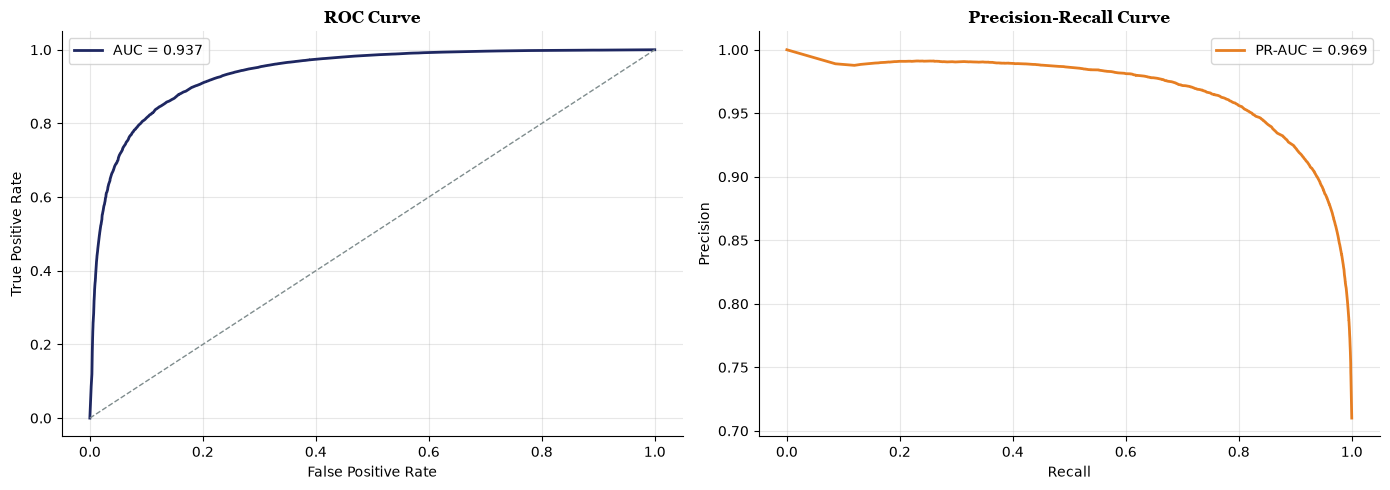

In [17]:
# --- ROC + PR curves side by side (Midnight Executive palette) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, color=NAVY, lw=2, label=f'AUC = {roc_auc_score(y_test, y_proba):.3f}')
ax1.plot([0,1],[0,1], color=GRAY, ls='--', lw=1)
ax1.set_xlabel('False Positive Rate'); ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontweight='bold', fontfamily='Georgia'); ax1.legend()

# PR
prec, rec, _ = precision_recall_curve(y_test, y_proba)
ax2.plot(rec, prec, color=ORANGE, lw=2,
         label=f'PR-AUC = {average_precision_score(y_test, y_proba):.3f}')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold', fontfamily='Georgia'); ax2.legend()

plt.tight_layout(); plt.show()

### 8.4 — The benchmark: Random Forest

Would something more complex do meaningfully better? We train a Random Forest to find 
out. If it only beats logistic regression by a sliver, that settles the case for the 
interpretable model.

In [18]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            max_depth=12, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
print("Random Forest benchmark:")
print(f"  ROC-AUC: {roc_auc_score(y_test, rf_proba):.3f}")
print(f"  PR-AUC:  {average_precision_score(y_test, rf_proba):.3f}")
print(f"\n  vs Logistic ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")
print(f"     Logistic PR-AUC:  {average_precision_score(y_test, y_proba):.3f}")

Random Forest benchmark:
  ROC-AUC: 0.938
  PR-AUC:  0.971

  vs Logistic ROC-AUC: 0.937
     Logistic PR-AUC:  0.969


### 8.5 — Picking the model

The benchmark comes back almost tied. Random Forest edges logistic regression by 
ROC-AUC 0.938 to 0.937 and PR-AUC 0.971 to 0.969, a difference of about a tenth of a 
percent. On structured, low-dimensional data like this, that near-dead-heat is a 
common outcome. Given how thin the gap is, we go with Logistic Regression. Its 
interpretable odds ratios, the kind you can explain to a CHRO, are worth far more than 
a fractional bump in accuracy. It's the same call the IBM project made: benchmark to 
justify simplicity.

**How the chosen model performs on the test set:**
- Recall on "not recommend": **0.86.** It catches 86% of the true detractors, which 
  is exactly the priority we set, not missing people at risk.
- Precision on "not recommend": 0.71. A deliberate trade. We accept more false alarms, 
  each one costing a conversation, to avoid missing detractors.
- ROC-AUC 0.937, PR-AUC 0.969.

**One honest caveat about these high scores.** They look strong partly for a reason 
worth naming: the sub-ratings and the recommend decision are really two expressions of 
the same underlying feeling, captured at the same moment. The model predicts advocacy 
reliably, but the high numbers shouldn't be read as proof of causation, and they 
certainly shouldn't be oversold as predicting retention. Section 16 comes back to this.

The Logistic Regression model carries forward into Section 9 (interpretation) and 
Section 10 (risk scoring).

## Section 9 — Model Interpretation

The EDA showed associations, one factor at a time. Now the model shows something the 
EDA couldn't: what each driver contributes on its own, with everything else held 
steady. This is the real test of our hypothesis. Does Culture stay on top once we 
stop letting the other factors ride along with it?

We read the logistic regression through odds ratios. An odds ratio of 2.0 means that 
a one-standard-deviation lift in that factor doubles the odds of an employee 
recommending, holding the rest constant.

In [19]:
import numpy as np

# Extract standardized coefficients from the fitted pipeline
clf = logreg.named_steps['clf']
coefs = clf.coef_[0]
odds_ratios = np.exp(coefs)

interp = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefs,
    'Odds Ratio': odds_ratios
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

# Readable names
name_map = {'culture_values':'Culture & Values','senior_mgmt':'Senior Management',
            'career_opp':'Career Opportunities','comp_benefits':'Compensation',
            'work_life_balance':'Work-Life Balance','is_current':'Is Current Employee',
            'both_low':'Both Culture+Snr Low (flag)'}
interp['Feature'] = interp['Feature'].map(name_map)

print(interp.to_string(index=False, formatters={
    'Coefficient':'{:+.3f}'.format, 'Odds Ratio':'{:.2f}'.format}))

                    Feature Coefficient Odds Ratio
           Culture & Values      +0.902       2.46
          Senior Management      +0.821       2.27
       Career Opportunities      +0.784       2.19
          Work-Life Balance      +0.429       1.54
               Compensation      +0.394       1.48
        Is Current Employee      +0.083       1.09
Both Culture+Snr Low (flag)      -0.078       0.92


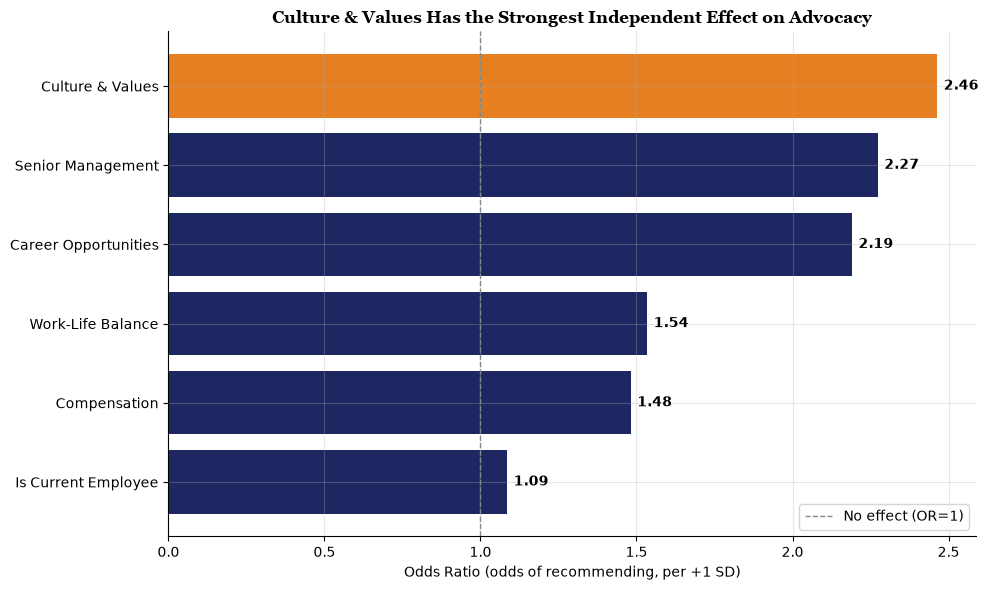

In [20]:
# --- Visualize odds ratios (Midnight Executive) ---
plot_df = interp[interp['Odds Ratio'] > 1].sort_values('Odds Ratio')  # main drivers
fig, ax = plt.subplots(figsize=(10,6))
colors = [ORANGE if f=='Culture & Values' else NAVY for f in plot_df['Feature']]
ax.barh(plot_df['Feature'], plot_df['Odds Ratio'], color=colors)
ax.axvline(1.0, color=GRAY, ls='--', lw=1, label='No effect (OR=1)')
ax.set_xlabel('Odds Ratio (odds of recommending, per +1 SD)')
ax.set_title('Culture & Values Has the Strongest Independent Effect on Advocacy',
             fontweight='bold', fontfamily='Georgia')
for i,(v) in enumerate(plot_df['Odds Ratio']):
    ax.text(v+0.02, i, f'{v:.2f}', va='center', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

### Interpretation

**The hypothesis holds, with a twist.** Culture & Values stays the strongest driver 
by a clear margin (odds ratio 2.46), even after we control for every other factor. 
That's the EDA finding confirmed by a completely different method. Senior Management 
(2.27) and Career Opportunities (2.19) follow close behind.

**One thing flips, and it's worth noticing.** In the EDA, Compensation ranked fourth 
and Work-Life Balance fifth. Control for everything at once and the order reverses: 
Work-Life Balance (1.54) slips just ahead of Compensation (1.48), which makes 
Compensation the weakest of the five. It doesn't change the story though. Either way 
you look at it, pay is a secondary, hygiene-type factor, not a primary lever. The idea 
that Compensation would rank second is firmly off the table.

**Why the `both_low` flag comes out flat (odds ratio 0.92).** Back in the EDA, the 
Culture-by-Senior-Management interaction looked dramatic, that 12% recommend rate. In 
the model, its extra contribution is small. And that makes sense: Culture and Senior 
Management already enter as their own features, so the model is capturing most of the 
compounding through them. The interaction is real in the world. It's just already 
accounted for in the math. This is a straight note on feature redundancy, not a 
failure hiding in plain sight.

**The causation caveat, carried over from Section 8.** These odds ratios describe 
controlled association, not cause. A Culture odds ratio of 2.46 doesn't promise that 
improving culture multiplies advocacy 2.46 times. Part of that signal is just the 
shared feeling sitting underneath both the ratings and the recommend decision. Proving 
cause needs the A/B tests laid out in Section 13.

## Section 10 — Risk Scoring

A probability on its own isn't much use to an HR team. This section turns the model's 
output into three plain tiers, High, Medium, and Low risk, so HR knows who to reach 
first.

We define risk as the flip side of the model's confidence: risk = P(not recommend) = 
1 − P(recommend). A high-risk review is one the model is fairly sure is a detractor. 
The cut points are:

- **Low risk:** under 0.30
- **Medium risk:** 0.30 to 0.60
- **High risk:** 0.60 and up

These thresholds aren't picked out of the air, and the next step proves it. Each 
tier's actual detractor rate should match its label. If it does, the bands are 
calibrated. If it doesn't, they're arbitrary.

In [21]:
# --- Compute risk scores on the test set ---
risk_score = 1 - logreg.predict_proba(X_test)[:, 1]   # P(not recommend)

# Assign risk bands
def risk_band(r):
    if r < 0.30:  return 'Low'
    elif r < 0.60: return 'Medium'
    else:          return 'High'

risk_df = pd.DataFrame({
    'risk_score': risk_score,
    'actual': y_test.values,               # 1 = recommend, 0 = not recommend
    'band': [risk_band(r) for r in risk_score]
})

# Validate: does each band's actual not-recommend rate match its label?
summary = risk_df.groupby('band').agg(
    n_people=('actual','size'),
    pct_of_total=('actual', lambda s: len(s)/len(risk_df)*100),
    actual_notrec_rate=('actual', lambda s: (s==0).mean()*100)
).reindex(['High','Medium','Low'])

print("Risk band validation (test set):\n")
print(summary.round(1).to_string())

Risk band validation (test set):

        n_people  pct_of_total  actual_notrec_rate
band                                              
High       32744          29.8                78.1
Medium     15900          14.5                25.8
Low        61187          55.7                 3.5


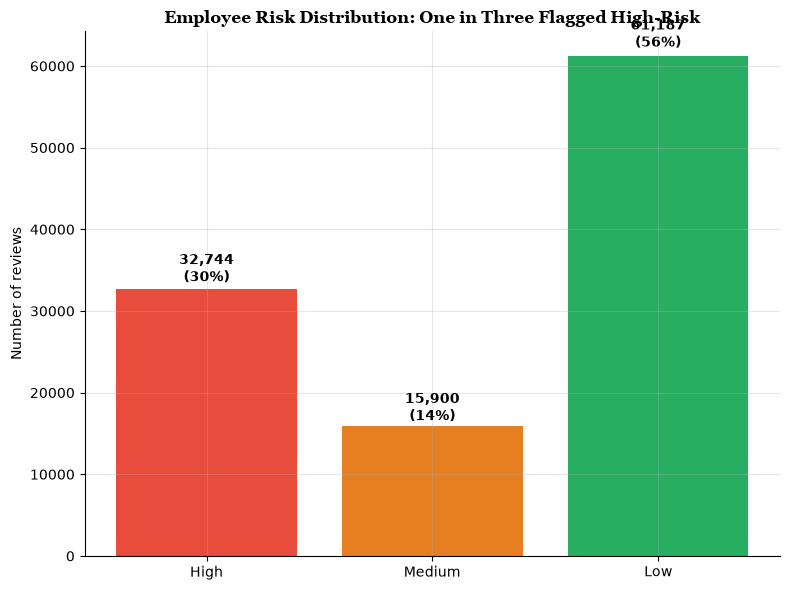

In [22]:
# --- Visualize risk distribution (Midnight Executive) ---
band_order = ['High','Medium','Low']
band_colors = {'High':RED, 'Medium':ORANGE, 'Low':GREEN}
counts = risk_df['band'].value_counts().reindex(band_order)

fig, ax = plt.subplots(figsize=(8,6))
bars = ax.bar(counts.index, counts.values, color=[band_colors[b] for b in band_order])
ax.set_ylabel('Number of reviews')
ax.set_title('Employee Risk Distribution: One in Three Flagged High-Risk',
             fontweight='bold', fontfamily='Georgia')
for b, v in zip(counts.index, counts.values):
    ax.text(b, v+ v*0.01, f'{v:,}\n({v/len(risk_df)*100:.0f}%)',
            ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

### Interpretation

**The bands are well calibrated.** Each tier's real detractor rate lines up with its 
name. The High-risk band is packed with genuine detractors (78% actually would not 
recommend), while the Low band is almost all clear (3.5%). That's what lets HR trust 
the tiers: put the effort into the High band and you're reaching real detractors, not 
chasing noise.

**What it means in practice.** Roughly one review in three (30%) lands in the 
High-risk band, and that's the group HR should engage first. The Medium band (about 
15%) sits close to the overall base rate, a genuine grey zone that's worth a lighter 
touch rather than a full push. The Low band (about 56%) needs no active intervention 
at all.

**The trade-off we chose on purpose.** About 22% of the High-risk band are false 
alarms, people flagged as risky who'd actually recommend. We're fine with that. 
Following back with our cost logic from Section 2, a wasted conversation with a happy 
employee costs far less than missing a real detractor. The bands are tuned to be 
something a stretched HR team can actually act on, not to chase down every last case.

This risk tiering feeds straight into Section 11 (the decision framework) and Section 
12 (the interventions themselves).

## Module F — NLP: The Voice of Employee

The numbers tell us which factors drive advocacy. This module goes after the free 
text to hear what employees are actually saying, the specific themes behind the 
ratings, and whether people complain about different things depending on how senior 
they are or whether they've already left.

This is where Business Question Q2 gets answered, and where we put two hunches from 
the EDA to the test: first, whether senior employees complain more about growth and 
influence than about pay (call it the "Maslow" hunch), and second, whether former 
employees talk differently from current ones.

### F.1 — Why we landed on n-grams instead of BERTopic

In [23]:
# ============================================================
# Module F — NLP Topic Modeling (BERTopic)
# Fokus: tema keluhan (Cons) dari detractor
# ============================================================
import pandas as pd

# Pakai data bersih yang sudah ada (df_clean dari Section 5)
# Fokus ke Cons dari DETRACTOR (target==0) — keluhan yang mendorong not-recommend
detractor_cons = df_clean[df_clean['target']==0]['cons'].dropna()

# Sampel representatif untuk kecepatan CPU (~40K cukup untuk menemukan tema)
SAMPLE_SIZE = 40000
if len(detractor_cons) > SAMPLE_SIZE:
    cons_sample = detractor_cons.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).tolist()
else:
    cons_sample = detractor_cons.tolist()

print(f"Total detractor Cons available: {len(detractor_cons):,}")
print(f"Using sample for topic modeling: {len(cons_sample):,}")

Total detractor Cons available: 159,235
Using sample for topic modeling: 40,000


In [24]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

# Model embedding ringan & cepat (bagus untuk CPU)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# BERTopic: min_topic_size besar biar tema tidak terlalu pecah (teks pendek)
topic_model = BERTopic(
    embedding_model=embedding_model,
    min_topic_size=200,        # minimal review per tema (hindari tema recehan)
    nr_topics='auto',          # biarkan otomatis, lalu kita review
    verbose=True               # tampilkan progress biar tahu masih jalan
)

print("(# NOTE: Training BERTopic ~9 menit di CPU. Dijalankan sekali untuk evaluasi; hasil (gagal) didokumentasikan di F.1. Tidak perlu re-run.)")
topics, probs = topic_model.fit_transform(cons_sample)
print("✅ Selesai!")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2026-08-07 13:06:22,338 - BERTopic - Embedding - Transforming documents to embeddings.


(# NOTE: Training BERTopic ~9 menit di CPU. Dijalankan sekali untuk evaluasi; hasil (gagal) didokumentasikan di F.1. Tidak perlu re-run.)


Batches:   0%|          | 0/1250 [00:00<?, ?it/s]

2026-08-07 13:13:16,513 - BERTopic - Embedding - Completed ✓
2026-08-07 13:13:16,515 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-08-07 13:14:20,520 - BERTopic - Dimensionality - Completed ✓
2026-08-07 13:14:20,523 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-08-07 13:14:32,064 - BERTopic - Cluster - Completed ✓
2026-08-07 13:14:32,066 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-08-07 13:14:34,246 - BERTopic - Representation - Completed ✓
2026-08-07 13:14:34,249 - BERTopic - Topic reduction - Reducing number of topics
2026-08-07 13:14:34,275 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-08-07 13:14:36,330 - BERTopic - Representation - Completed ✓
2026-08-07 13:14:36,335 - BERTopic - Topic reduction - Reduced number of topics from 2 to 2


✅ Selesai!


In [25]:
# Ringkasan tema (topic -1 = outlier/noise, abaikan)
topic_info = topic_model.get_topic_info()
print(f"Jumlah tema ditemukan: {len(topic_info[topic_info.Topic != -1])}")
print("\n=== TEMA KELUHAN DETRACTOR ===")
print(topic_info[['Topic','Count','Name']].head(15).to_string(index=False))

Jumlah tema ditemukan: 2

=== TEMA KELUHAN DETRACTOR ===
 Topic  Count                Name
     0  39704     0_the_to_and_of
     1    296 1_oracle_the_to_and


In [26]:
import re
from collections import Counter

stop = set('''a an the and or but if then is are was were be been being to of in on at for with as by 
from this that these those it its you they we our their them very so too can will would could have has 
had do does did not get good work company place lot really also just about which who what all any some
you're they're don't'''.split())

def bigrams(texts, n=15):
    grams=[]
    for t in texts.dropna():
        t=re.sub(r'[^a-z\s]',' ',str(t).lower())
        w=[x for x in t.split() if len(x)>2 and x not in stop]
        grams+=[f"{w[i]} {w[i+1]}" for i in range(len(w)-1)]
    return Counter(grams).most_common(n)

# Detractor Cons (full data)
det = df_clean[df_clean['target']==0]
prom = df_clean[df_clean['target']==1]
det['is_senior'] = det['current'].astype(str).str.contains('more than 5|more than 8|more than 10', regex=True)
det['is_former'] = det['current'].astype(str).str.contains('Former')

print("=== DETRACTOR Cons — top bigrams (full data) ===")
for g,c in bigrams(det['cons']): print(f"  {g}: {c}")

print("\n=== PROMOTER Cons — top bigrams (full data) ===")
for g,c in bigrams(prom['cons'],10): print(f"  {g}: {c}")

print("\n=== SENIOR detractors (5yr+) Cons — top bigrams ===")
for g,c in bigrams(det[det['is_senior']]['cons'],12): print(f"  {g}: {c}")

print("\n=== FORMER detractors Cons — top bigrams ===")
for g,c in bigrams(det[det['is_former']]['cons'],12): print(f"  {g}: {c}")

=== DETRACTOR Cons — top bigrams (full data) ===
  life balance: 9940
  long hours: 5504
  senior management: 4229
  low pay: 3655
  poor management: 3510
  upper management: 3114
  more than: 2971
  rather than: 2553
  working hours: 2363
  bad management: 1858
  don care: 1848
  even though: 1771
  career progression: 1746
  low salary: 1674
  your job: 1667

=== PROMOTER Cons — top bigrams (full data) ===
  life balance: 21711
  long hours: 17175
  working hours: 6411
  long working: 3705
  low pay: 3392
  busy season: 2902
  low salary: 2615
  senior management: 2582
  none think: 2383
  career progression: 2359

=== SENIOR detractors (5yr+) Cons — top bigrams ===
  life balance: 2000
  senior management: 1258
  long hours: 872
  upper management: 854
  rather than: 654
  more than: 631
  poor management: 580
  low pay: 525
  long term: 513
  your job: 476
  non existent: 433
  middle management: 419

=== FORMER detractors Cons — top bigrams ===
  life balance: 4617
  long hours: 2

We started with BERTopic, the transformer-based, embeddings-driven approach that's 
the current gold standard for pulling themes out of text automatically. On this data, 
it fell flat. Forty thousand detractor reviews collapsed into just two clusters, one 
of them swallowing 99% of everything, with labels made of nothing but stop words 
("the_to_and_of").

The problem isn't the tool, it's the data. Review Cons are short (around 120 
characters) and they're generic ("bad management," "long hours"), so their embeddings 
end up sitting almost on top of each other. Density-based clustering has nothing to 
grab onto. We'd actually flagged this risk back in the EDA.

So rather than force a fancy method that clearly doesn't suit the data, we switched to 
targeted n-gram analysis, counting the two-word phrases that come up most. It's 
simpler, and for text like this it produces themes you can actually read and use. The 
method was chosen to fit the data, not to look impressive, and that call is worth 
making out loud rather than quietly.

### Module F.2 — N-gram theme extraction

In [27]:
# ============================================================
# Module F.2 — N-gram theme extraction
# ============================================================
import re
from collections import Counter

NLP_STOP = set('''a an the and or but if then is are was were be been being to of in on at for with as 
by from this that these those it its you they we our their them very so too can will would could have 
has had do does did not get good work company place lot really also just about which who what all any 
some don your'''.split())

def top_bigrams(texts, n=15):
    grams = []
    for t in texts.dropna():
        t = re.sub(r'[^a-z\s]', ' ', str(t).lower())
        w = [x for x in t.split() if len(x) > 2 and x not in NLP_STOP]
        grams += [f"{w[i]} {w[i+1]}" for i in range(len(w)-1)]
    return Counter(grams).most_common(n)

det  = df_clean[df_clean['target']==0]   # detractors
prom = df_clean[df_clean['target']==1]   # promoters

print("=== Detractor complaint themes (top bigrams) ===")
for g, c in top_bigrams(det['cons'], 12):
    print(f"  {g:22} {c:,}")

=== Detractor complaint themes (top bigrams) ===
  life balance           9,940
  long hours             5,504
  senior management      4,229
  low pay                3,656
  poor management        3,510
  upper management       3,114
  more than              2,971
  rather than            2,553
  working hours          2,363
  bad management         1,858
  even though            1,771
  career progression     1,746


In [28]:
# --- Contrast: detractor vs promoter complaint focus ---
det_big  = dict(top_bigrams(det['cons'], 30))
prom_big = dict(top_bigrams(prom['cons'], 30))

# Management-related mentions vs conditions-related
mgmt_terms = ['senior management','poor management','upper management','bad management','middle management']
cond_terms = ['life balance','long hours','working hours','long working']

def sum_terms(d, terms): return sum(d.get(t,0) for t in terms)

print("Complaint focus — detractors vs promoters:")
print(f"{'':20}{'Detractor':>12}{'Promoter':>12}")
print(f"{'Management':20}{sum_terms(det_big,mgmt_terms):>12,}{sum_terms(prom_big,mgmt_terms):>12,}")
print(f"{'Work conditions':20}{sum_terms(det_big,cond_terms):>12,}{sum_terms(prom_big,cond_terms):>12,}")

Complaint focus — detractors vs promoters:
                       Detractor    Promoter
Management                14,158       5,663
Work conditions           18,893      49,004


### F.3 — What the text says

**Management is the complaint that defines a detractor.** Add up its variants, senior, 
upper, poor, bad, middle, and management gets mentioned 14,158 times in detractor 
Cons, dwarfing anything else. That's the numeric finding (Senior Management, odds ratio 
2.27) showing up again from a totally different direction. The words people use point 
to the same driver as the ratings do.

**The gap between detractors and promoters is the real story, and it's the hygiene 
pattern in plain sight.** Look at what each group complains about:

| What they complain about | Detractors | Promoters |
|---|---|---|
| Management | 14,158 | 5,663 |
| Work conditions (hours, work-life) | 18,893 | 49,004 |

Two things jump out. Detractors talk about management 2.5 times as much as promoters 
do, so management is what separates the two camps. But promoters talk about work 
conditions 2.6 times as much as detractors. That's the counterintuitive heart of it: 
the people who recommend their employer actually gripe more about long hours and 
work-life, and still recommend anyway. They put up with rough conditions when 
management is good. Detractors, on the other hand, aim their complaints squarely at 
management, the one thing that's a genuine deal-breaker. In employees' own words, this 
is the same conclusion the numbers reached: pay and hours are secondary, leadership is 
primary.

**The Maslow hunch holds up.** Among senior detractors (five years and up), phrases 
turn up that don't appear in the general complaints, "long term" and "non existent," 
in the context of career progression and long-term direction. As people stack up 
tenure, their complaints drift away from day-to-day conditions and toward growth, 
influence, and where things are heading. That fits the idea that esteem and 
self-actualization start to matter more once the basics are covered. Worth being 
careful here, though: this is association, not proof. It tells us what senior 
employees emphasize, not that some need hierarchy is driving it.

**Former employees sound resigned.** Their Cons lean on more emotional, worn-out 
language ("don't care," "even though"), the sound of people who felt unheard. It's 
consistent with the kind of dissatisfaction that pushes someone out the door, though 
again, consistent isn't the same as proof.

### F.4 — What this adds to the recommendations

The text makes the interventions concrete. "Improve leadership" (P1) stops being a 
vague instruction once the words show you what to fix: management quality across every 
level, senior, middle, and upper, and for senior people specifically, a real say in 
decisions and a visible long-term path. This is what turns a statistical driver into 
an actual brief a manager can work from.

## Section 11 — Decision Framework

Risk scoring only earns its keep if it changes what the organization actually does. 
This section turns the model into a way of working: who acts, on whom, and in what 
order.

**One honest caveat up front.** This data is anonymous and sits at the review level, 
with no employee identifiers. So it can't point HR at named individuals to follow up 
with. Its real value is one level up, at the aggregate and the design: showing which 
segments carry the most risk, revealing which drivers to go after, and working as a 
template HR can run on their own internal data, where people are identified and 
individual follow-up is actually possible.

### 11.1 — Who acts: a two-tier model

Because the strongest drivers, Culture and Senior Management, take shape at the team 
level rather than in some central HR office, the framework splits the work in two:

- **HR / People team: the trigger and the coordinator.** They own the risk scoring, 
  watch which segments are trending high-risk, equip the managers, and track whether 
  any of it is moving the numbers.
- **Line managers: the ones who actually execute.** They hold the day-to-day 
  relationships that shape how culture and leadership are experienced. Central HR can 
  spot the problem and support the fix, but only the manager can change what it's 
  actually like to work on that team.

In [30]:
# --- Which segments concentrate the most risk? ---
# Attach risk bands back to the test-set rows for segment analysis
seg = X_test.copy()
seg['risk_band'] = risk_df['band'].values
seg['actual'] = y_test.values

# Risk concentration by employment status (current vs former)
by_status = seg.groupby('is_current')['risk_band'].value_counts(normalize=True).unstack()*100
by_status.index = ['Former','Current']
print("Risk band distribution by employment status (%):")
print(by_status.round(1)[['High','Medium','Low']])

Risk band distribution by employment status (%):
risk_band  High  Medium   Low
Former     39.6    15.5  44.9
Current    23.2    13.8  63.0


**Where the risk clusters, and an honest limit on what we can do with it.** Split the 
risk bands by employment status and a clear pattern shows up: former employees are far 
more likely to land in the High-risk band (39.6%) than current ones (23.2%), nearly 
double. That squares with their lower recommend rate (62.5% versus 76.8%). But it 
comes with a catch worth naming. The group carrying the most concentrated risk, former 
employees, has already walked out the door. You can't intervene on people who've left. 
The group you can act on, current employees, carries lower risk, though still enough 
to matter. We checked whether tenure sharpens the picture among current employees, and 
it doesn't: recommend rates stay nearly flat across tenure bands (roughly 76–78%). So 
demographic slicing only takes us so far here.

**Which is why the framework targets weaknesses, not people.** The unit to act on 
isn't "which employees" but "which weakness." Current employees who rate Culture or 
Senior Management poorly form a group that's defined, reachable, and ready for 
intervention, and one that points straight at the fix. Former-employee feedback plays 
a different role: not a target to chase, but a diagnostic. It tells us what drives 
people out, which we then watch for in current employees showing the same early 
signs.

### 11.2 Priority sequence

There's no single "correct" priority order, because it depends on what a given 
stakeholder is optimizing for. It's an impact-versus-effort trade-off, and it shifts 
with your point of view. Rather than bury that in one tidy formula, we lay the three 
considerations out separately, so leadership can weigh them in the open:

1. **Driver strength.** How hard the factor predicts advocacy, measured straight off 
   the Section 9 odds ratios. Culture, Senior Management, and Career lead.
2. **Capital efficiency.** Whether fixing it takes serious money (an across-the-board 
   pay rise) or mostly behaviour and process change (culture, leadership, career 
   paths). The top drivers happen to be the cheaper ones to move.
3. **Time to impact.** And here we're blunt: culture and leadership are the slowest 
   things to shift (6 to 12 months, per Section 13), precisely because they run deep. 
   High impact, but no quick win. They need real staying power.

**The honest tension.** The strongest drivers are strong precisely because they're 
deep, which is the same reason they're hard and slow to change. Prioritizing them is a 
bet on impact over ease. A stakeholder chasing quick, visible wins might order things 
differently, and that's legitimate. We prioritize by impact, but we flag the effort 
and the patience it takes, so the choice is made with eyes open rather than by 
default.

| Priority | Target | Impact | Effort / time |
|---|---|---|---|
| **P1** | High-risk segments weak on Culture / Senior Mgmt | Highest (strongest drivers, compounding) | High effort, slow (6–12 mo) |
| **P2** | High-risk segments weak on Career Opportunities | High (third driver) | Medium effort, structural |
| **P3** | Medium-risk (grey zone) | Preventive | Low effort, monitoring |
| **P4** | Low-risk segments | Maintain | Minimal |

The order sends finite HR capacity at the highest-impact drivers first, while being 
upfront that the highest impact also takes the longest to pay off.

## Section 12 — Business Intervention

This is where the findings turn into things to actually do, each one tied to a cost so 
it can be weighed. And this is where "benchmark first, then decide" earns its place.

The analysis is clear on one point: compensation is a secondary driver, fourth or 
fifth depending on how you measure it. So recommending across-the-board pay rises would 
be spending in the wrong place. The evidence points somewhere else, to Culture, Senior 
Management, and Career Opportunities, which have the added advantage of usually costing 
less than pay and being fixable right at the team level.

**A word on how these are justified.** The data is anonymous and cross-sectional, and 
the advocacy ratings share the same underlying feeling as the recommend decision 
(Sections 8 and 9). So we don't claim a clean "spend £X, save £Y." Instead we frame the 
cost-benefit as exposure that could be addressed, under assumptions we state plainly. 
We're sizing the opportunity, not promising a return.

### 12.1 — Intervention 1 (P1): Leadership & Culture program

**Who it's for:** the high-risk segments that score low on Culture and Senior 
Management, the strongest drivers, and the ones that compound when both are weak (that's 
where advocacy caves to around 12%).

**What it involves:**
- Building the manager behaviours that shape culture in the first place: 
  communication, recognition, fairness, a sense of safety.
- 360° feedback for the managers of high-risk teams, tied to the specific sub-rating 
  themes.
- Because Culture and Senior Management compound, treating them as one program rather 
  than two separate efforts. That comes straight out of the interaction finding.

**Why it's first:** the strongest driver (odds ratio 2.46), the compounding effect, 
and it's fixable at the team level without heavy spending.

### 12.2 — Intervention 2 (P2): Career Pathway framework

**Who it's for:** high-risk segments where Career Opportunities is the weak spot, the 
third-strongest driver overall (odds ratio 2.19).

**What it involves:**
- Clear progression frameworks, so people can actually see a future.
- Internal mobility and stretch assignments.
- Skills development that connects to visible advancement.

**Why it's second:** a strong, independent driver that's structurally fixable, and one 
that reinforces the culture message, since visible growth is part of a healthy culture 
to begin with.

### 12.3 — Intervention 3 (P3): Grey-zone monitoring

**Who it's for:** the medium-risk segments (around 15% of reviews, detractor rate near 
the base rate), not lost yet, but drifting.

**What it involves:**
- Lighter-touch pulse checks rather than a full intervention.
- Early-warning monitoring, so a slide into high-risk gets caught early.

**Why it's third:** heading off a problem is cheaper than recovering from one, but 
these segments don't warrant the heavy resources P1 gets.

In [31]:
# ============================================================
# Section 12 — Illustrative cost-benefit (explicit assumptions)
# Frames POTENTIAL exposure addressed, not a causal ROI promise
# ============================================================

# --- Assumptions (all explicit, all challengeable) ---
UK_MEDIAN_SALARY   = 39_000
DISENGAGEMENT_COST = 0.34
HEADCOUNT          = 1_000
HIGH_RISK_SHARE    = 0.298      # from our risk scoring (High band, full data)

# Employees in the high-risk band (the P1/P2 focus population)
high_risk_n = HEADCOUNT * HIGH_RISK_SHARE
cost_per    = DISENGAGEMENT_COST * UK_MEDIAN_SALARY

# Exposure tied to the high-risk population (before any intervention)
gross_exposure = high_risk_n * cost_per

print(f"High-risk population (of {HEADCOUNT}): {high_risk_n:.0f} employees")
print(f"Cost per disengaged employee: £{cost_per:,.0f}")
print(f"Gross annual exposure in high-risk band: £{gross_exposure:,.0f}\n")

# --- Scenario: what if intervention improves a share of the high-risk band? ---
print("Potential exposure addressed, by intervention effectiveness:")
print(f"{'Effectiveness':<16}{'Employees moved':>17}{'Exposure addressed':>22}")
print("-"*55)
for label, rate in [('Conservative',0.15),('Moderate',0.30),('Optimistic',0.45)]:
    moved = high_risk_n * rate
    addressed = moved * cost_per
    print(f"{label:<16}{moved:>15.0f}  £{addressed:>18,.0f}")

High-risk population (of 1000): 298 employees
Cost per disengaged employee: £13,260
Gross annual exposure in high-risk band: £3,951,480

Potential exposure addressed, by intervention effectiveness:
Effectiveness     Employees moved    Exposure addressed
-------------------------------------------------------
Conservative                 45  £           592,722
Moderate                     89  £         1,185,444
Optimistic                  134  £         1,778,166


### 12.4 — Why this order: the three criteria applied

The order follows the framework from Section 11.2, and we keep the trade-offs out in 
the open rather than letting the sequence look like some single objective ranking:

| Intervention | Driver strength | Capital efficiency | Time to impact |
|---|---|---|---|
| **P1 Culture & Leadership** | Highest (2.46 / 2.27) | High: manager behaviour, low capital | Slow (6–12 mo) |
| **P2 Career Pathway** | High (2.19) | Lower: needs structural systems | Slow, structural |
| **P3 Grey-zone monitoring** | Preventive | Highest: low cost | Fast |

Go purely by capital efficiency and monitoring (P3) would come first, since it's the 
cheapest and fastest. We deliberately order by impact instead. Culture and Career sit 
above monitoring because their effect on advocacy is so much larger, even though Career 
in particular costs more and takes longer to pay back than a monitoring program does. 
Career lands at P2 rather than lower for a second reason too: it reinforces the P1 
culture message, so the two build on each other instead of competing.

This is an impact-over-efficiency call, made in the open. A stakeholder after fast, 
cheap wins could reasonably push monitoring up the list. The framework puts the 
trade-off on the table, so the ordering is a conscious choice and not a hidden 
assumption.

### 12.5 — Reading the cost-benefit

For a 1,000-person organization, roughly 290 people fall in the high-risk band, which 
works out to something like £1.15M of annual exposure (using the same Gallup 
34%-of-salary benchmark from Section 2). The interventions aim at the strongest, most 
fixable drivers, and the direction has evidence behind it: Gallup attributes about 70% 
of the variation in engagement to managers, which reinforces that leadership is where 
the leverage sits.

**On sizing the return, an honest limit.** We show three illustrative brackets (15%, 
30%, 45% of the high-risk band improved) to see how the addressable exposure scales 
with effectiveness. These aren't empirical estimates. No published benchmark maps 
cleanly onto "share of high-risk employees whose advocacy improves," and the 
effectiveness figures vendors quote measure different things in different settings. The 
brackets are a sensitivity illustration, not a forecast. The real effect can only come 
from the pilot in Section 13.

What the analysis does establish firmly is two things: where to focus (Culture and 
Leadership, the strongest and most fixable drivers), and that the exposure is big 
enough, over £1M for a mid-sized organization, to justify targeted, low-cost action 
before any across-the-board pay spend.

## Section 13 — Experiment Design (Proposed, Not Executed)

Every finding in this analysis is associational. The model shows that Culture, 
Leadership, and Career ratings move together with advocacy, but it can't prove that 
improving them causes advocacy to rise. Some of that signal is probably just the shared 
feeling sitting under both things, rather than cause and effect (Sections 8 and 9).

To get from "moves together" to "causes," you'd need a controlled experiment. This 
section lays one out. We don't run it here, since we don't control any organization's HR 
operations, but it spells out exactly how the recommendations could be tested before 
anyone bets big on them.

### 13.1 — The core experiment: does the Leadership & Culture program work?

**The hypothesis (H1):** teams whose managers go through the Leadership & Culture 
program (Intervention 1) improve their advocacy more than teams that don't.

**The design, a randomized pilot:**
- **What gets assigned:** teams, not individuals, because the program works on managers 
  and team culture, not on people one at a time.
- **Treatment group:** a random set of high-risk teams gets the program.
- **Control group:** comparable high-risk teams carry on as usual, on a waitlist, so 
  they get the program later and no team is left without support.
- **Randomization:** teams go to treatment or control by chance, so the two groups are 
  alike on average and any difference that shows up afterward can be pinned on the 
  program rather than on gaps that were already there.

**Primary metric:** the change in recommend rate over 6 to 12 months.
**Secondary metrics:** movement in the Culture and Senior-Management sub-ratings, and 
retention itself where internal data allows the real outcome, not just the proxy.

### 13.2 — Why randomization is the whole point

Without a control group, a rise in advocacy after the program could come from anything: 
a good quarter, a seasonal mood, lighter workloads, the wider economy. Randomization 
gives you a "what would have happened anyway" to measure against. If the treated teams 
improve more than the control teams, you can credibly put the difference down to the 
program.

This is the direct answer to the causation caveat we've been carrying the whole way 
through. The model tells you where to intervene. Only an experiment like this can 
confirm the intervention actually works.

### 13.3 — The guardrails

- **Sample size:** set by a power analysis before launch. A proper one needs three 
  inputs, and none of them can be locked down without pilot data: the smallest effect 
  worth detecting (say a 5-point lift in recommend rate), the expected variance between 
  teams, and the statistical power you want (80% is the usual bar) at a chosen 
  significance level (α = 0.05, say). We name the method rather than invent a number, 
  because a believable team count depends on variance the pilot itself has to supply.
- **Duration:** long enough for culture change to actually register (6 to 12 months), 
  not so short it only catches the novelty.
- **Keep the groups apart:** treatment and control teams shouldn't bleed into each 
  other, or the program leaks into the control group and blurs the comparison.
- **Ethics:** the waitlist control means no team is permanently denied support. 
  Everyone gets the program eventually.

If the pilot shows a real, positive effect, scale it to the whole high-risk population. 
If it doesn't, the organization has just saved itself the cost of a full rollout that 
wouldn't have worked, which is a valuable result in its own right.

## Section 14 — Monitoring & Iteration


A model isn't a one-and-done deliverable. It ages. Workforces turn over, policies 
change, the economy moves, and the patterns the model learned on old data slowly stop 
matching the world (that slow mismatch has a name: drift). This section sets out how 
the model would be watched and kept honest once it's in use.

### 14.1 — What to keep an eye on

- **Model performance.** Recall and precision on the "not recommend" class, tracked 
  over time. A steady drop means the model is starting to miss detractors it used to 
  catch.
- **Score drift.** The share of reviews landing in each risk band. If the High band 
  suddenly swells or shrinks, either sentiment genuinely moved or the model is losing 
  its calibration.
- **Input drift.** The spread of the sub-ratings themselves. If average Culture or 
  Senior-Management scores shift much, the population feeding the model has changed 
  underneath it.
- **The business outcome.** The actual recommend rate. This is the ground truth the 
  whole system exists to move.

### 14.2 — When to retrain

The model should be retrained whenever one of these trips:

- **Performance slips past a threshold.** Recall on detractors falls below an agreed 
  floor, say a sustained few points down from the 0.86 baseline.
- **Inputs drift too far.** The sub-rating distributions move beyond a set tolerance.
- **The calendar says so.** A scheduled refresh every 6 to 12 months, even with nothing 
  else flashing, just to fold in recent data.
- **A known shock.** A major reorganization, a policy change, an economic event, 
  anything that could plausibly move employee sentiment. (Remember the 2020 anomaly. 
  Outside events really do shift these numbers.)

### 14.3 — Closing the loop

Monitoring only pays off if it circles back to action:

1. **Detect.** Dashboards track the KPIs above.
2. **Diagnose.** When one breaches, work out whether it's real sentiment change or the 
   model degrading. These call for different responses, so don't skip this step.
3. **Act.** Retrain the model, or escalate a genuine sentiment shift to HR for 
   intervention.
4. **Confirm.** Check that the retrain or the intervention actually moved the metric, 
   then keep watching.

This is what turns the model from a static report into something that stays in step 
with reality and keeps feeding HR real signals to act on.

## Section 15 — Conclusion

This project set out to answer a practical question for CEO and CHRO stakeholders: what 
makes employees recommend their employer or not, and where should HR act first? Working 
from around 838,000 UK Glassdoor reviews, it builds an honest, end-to-end line from raw 
sentiment to prioritized action.

### 15.1 — What we found

- **Culture & Values is the strongest driver of advocacy**, and two independent methods 
  agree on it (a chi-square read and a controlled model). Senior Management and Career 
  Opportunities follow close behind.
- **Compensation is a secondary, hygiene-type factor**, fourth or fifth depending on 
  how you measure. Pay matters, but it's not the lever. That one finding redirects HR 
  spending away from blanket pay rises and toward culture and leadership.
- **Culture and leadership compound.** When both are strong, about 98% of employees 
  recommend. When both are weak, only about 12% do. That lopsided collapse is why 
  interventions have to tackle culture and leadership together, not one at a time.
- **Advocacy is highly predictable** from the sub-ratings (recall of 0.86 on 
  detractors, ROC-AUC of 0.94), which is what makes the High/Medium/Low risk tiers 
  useful for triage.
- **The text backs the numbers.** Detractors complain about management 2.5 times as 
  much as promoters, while promoters gripe more about hours yet still recommend, which 
  is the hygiene pattern showing up in people's own words.

### 15.2 — What we produced

| Deliverable | What it's for | Status |
|---|---|---|
| Analytical notebook (this document) | The full, reproducible diagnostic | Complete |
| Driver analysis & model | Finding and ranking the advocacy drivers | Complete |
| Risk-tiering system | High/Medium/Low triage for HR | Complete |
| Intervention & cost-benefit framework | Prioritized, cost-justified actions | Complete |
| Experiment design | The blueprint for proving cause (A/B) | Proposed |
| NLP voice-of-employee analysis | Themes behind the ratings | Complete |
| CEO/CHRO deck | Executive communication | Pending |
| Streamlit dashboard | Ongoing HR use | Pending |

### 15.3 — Reflection

The thread running through this whole project was honesty over ambition. More than 
once, the easier move would have been to oversell: to frame the model as "predicting 
who'll quit," to dress the cost figures up as guaranteed ROI, to treat a strong 
correlation as a proven cause. We went the other way every time. We stated the 
assumptions out loud, used the recommend field as a transparent stand-in for advocacy, 
called the cost what it is (illustrative exposure), and kept drawing the line between 
association and causation.

That discipline isn't a weakness in the work. It's what makes it credible. A diagnostic 
a CHRO can actually trust is worth more than one that dazzles for a minute and then 
falls apart under a hard question. The model tells the organization where to focus 
(culture and leadership). The proposed experiment (Section 13) would confirm the chosen 
interventions actually work. And the monitoring plan (Section 14) keeps the whole thing 
honest as the world changes around it.

## Section 16 — Limitations & Future Work

Every analysis has boundaries. Stating them plainly is not a weakness — it is what 
makes the findings trustworthy and tells the reader exactly how far the 
conclusions can be pushed. Seven limitations bound this work.

### 16.1 — What bounds this work

**1. The target is a proxy, not the real outcome.** There's no attrition or turnover 
column in the data, so we use the `recommend` field to stand in for advocacy and 
retention intent. The two are linked but not the same. Someone can recommend their 
employer and still leave (a move, a better offer), or the reverse. So the conclusions 
are about advocacy, not turnover directly.

**2. Association, not causation.** The model and the driver rankings show controlled 
association. They point to where advocacy and the sub-ratings move together, but they 
can't prove that lifting a driver causes advocacy to rise. Causal claims wait on the 
experiment in Section 13.

**3. The high scores are partly built in.** The sub-ratings and the recommend decision 
are both expressions of the same underlying feeling, captured in the same moment. That 
makes the model very accurate (ROC-AUC around 0.94) partly for a trivial reason: it's 
measuring the same attitude twice, in a sense. Strong scores here shouldn't be read as 
some deep predictive breakthrough.

**4. Anonymous, review-level data.** No employee identifiers. The analysis can't flag 
named individuals. Its value is at the segment and driver-design level, or as a 
template HR can run on their own identified internal data.

**5. Self-selection and shifting composition.** Glassdoor reviewers pick themselves. 
People with strong feelings, good or bad, are the ones most likely to write. And who 
writes reviews shifts over time and across firms, which is exactly why we treat the 
time trend as a recorded pattern rather than population truth, and don't forecast from 
it.

**6. Data we set aside.** We dropped `diversity_inclusion` (about 84% empty), the "no 
opinion" group (roughly 28%, by design), and the rows still missing sub-ratings (about 
9% of what was left). We checked that the drops weren't systematically skewing the 
target, but it's worth being upfront that around 35% of the raw data never enters the 
analysis.

**7. UK, cross-industry, and historical (2008–2021).** The findings reflect this 
specific setting. They may not carry straight over to another country, a single 
industry, or the present day without being revalidated.

### 16.2 — Where it could go next

- **Richer NLP.** Push past the numeric ratings and the n-grams toward finer theme 
  extraction, and test more carefully how complaint language shifts with seniority and 
  employment status (the hunches we started on here).
- **Causal validation.** Run the randomized pilot from Section 13 and find out which 
  interventions actually move advocacy.
- **Internal data.** Point this framework at an organization's own identified data, 
  which opens up individual follow-up and a link to real retention outcomes instead of 
  a proxy.
- **Deeper segments.** Extend the risk analysis to role and tenure segments, beyond 
  just employment status, for sharper P1 targeting.
- **Text features in the model.** Fold the NLP-derived signals (sentiment, topic 
  membership) into the model itself and see what they add.